In [1]:
!pip install tensorflow

In [2]:
# 1. Import Library
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [3]:
# 2. Atur Path Dataset
# Struktur folder harus seperti ini:
# dataset/
# ├── kelas_1/
# ├── kelas_2/
# └── kelas_3/

DATASET_PATH = "D:/Tugas Kuliah Ahdan/flower_images"   # ganti sesuai lokasi folder dataset kamu

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 123

In [4]:
# 3. Load Dataset Training dan Testing

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 4999 files belonging to 5 classes.
Using 4000 files for training.
Found 4999 files belonging to 5 classes.
Using 999 files for validation.


In [5]:
# 4. Cek Nama Kelas

class_names = train_ds.class_names
num_classes = len(class_names)

print("Nama kelas:", class_names)
print("Jumlah kelas:", num_classes)

Nama kelas: ['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip']
Jumlah kelas: 5


In [6]:
# 5. Optimasi Dataset

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [7]:
# Data Augmentation dan Normalisasi
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

normalization_layer = tf.keras.layers.Rescaling(1./255)

In [8]:
# 7. Membuat Arsitektur CNN

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,
    normalization_layer,

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

In [9]:
# 8. Compile Model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# 9. Tampilkan Tabel Parameter Model

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# 10. Training Model

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 408ms/step - accuracy: 0.4412 - loss: 1.3327 - val_accuracy: 0.5616 - val_loss: 1.1661
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 51s 411ms/step - accuracy: 0.5410 - loss: 1.1624 - val_accuracy: 0.5646 - val_loss: 1.0855
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 47s 377ms/step - accuracy: 0.5805 - loss: 1.0675 - val_accuracy: 0.6126 - val_loss: 0.9803
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 49s 396ms/step - accuracy: 0.6085 - loss: 1.0191 - val_accuracy: 0.5906 - val_loss: 1.0133
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 47s 373ms/step - accuracy: 0.6155 - loss: 0.9811 - val_accuracy: 0.6286 - val_loss: 0.9367
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 361ms/step - accuracy: 0.6338 - loss: 0.9331 - val_accuracy: 0.6927 - val_loss: 0.8073
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 368ms/step - accuracy: 0.6585 - loss: 0.8965 - val_accuracy: 0.6527 - val_loss: 0.8614
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 353ms/step - accuracy: 0.6745 - loss: 0

In [12]:
# 11. Evaluasi Model

loss, accuracy = model.evaluate(test_ds)

print("Loss:", loss)
print("Accuracy:", accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.7297 - loss: 0.7029
Loss: 0.7029030919075012
Accuracy: 0.7297297120094299


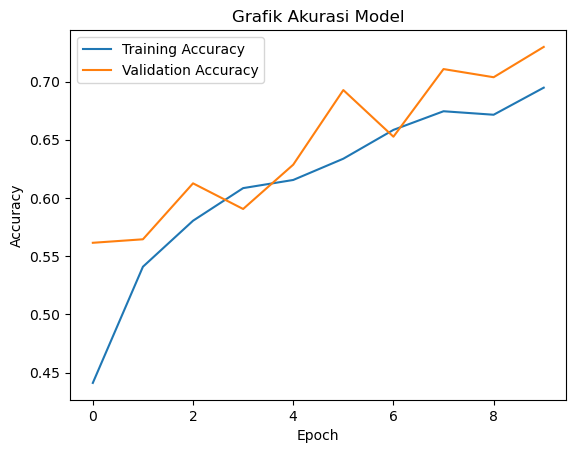

In [13]:
# 12. Grafik Akurasi

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Grafik Akurasi Model')
plt.show()

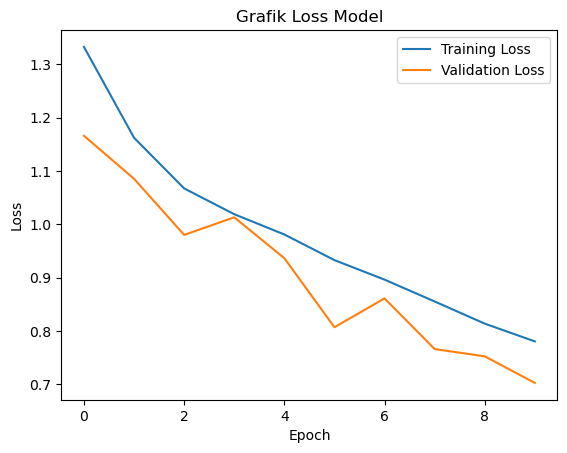

In [14]:
# 13. Grafik Loss

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Grafik Loss Model')
plt.show()